# 04_概率分布-Dirichlet分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们好好聊聊 Dirichlet 分布的内容\~

Dirichlet 分布是一个多维的连续概率分布，通常用于生成 k 个值的概率向量，这些值的总和为 1。

换句话说，Dirichlet 分布生成的是一组在 $[0, 1]$ 区间内的值，每个值都表示某一类别的概率，这些概率的和始终等于 1。

我们可以将其看作是一种从一个“多项式分布”的概率空间中采样的方法。

### 生活中的一个例子

设想我们有一个由 3 个不同的颜色组成的袋子，分别是红色、绿色和蓝色，我们想要描述袋子中这三种颜色的概率分布。

假设我们并不确切知道每种颜色的具体比例，但我们想用 Dirichlet 分布来为我们提供一种合理的估计方法。我们通过 Dirichlet 分布生成一个概率向量（比如 $[0.4, 0.3, 0.3]$），这意味着袋子中红色的比例为 40%，绿色的比例为 30%，蓝色的比例为 30%。

**为什么选择 Dirichlet 分布？**

- **生成概率分布：** Dirichlet 分布生成的结果是一个概率向量，每个元素的值表示该类别的概率。
- **共轭先验：** Dirichlet 分布是多项式分布的共轭先验，在贝叶斯推断中非常重要。
- **多样化的形状：** Dirichlet 分布可以通过调整其参数来生成不同形态的概率分布。例如，当所有的 α 值相等时，得到的结果是均匀分布；当某些 α 值远大于其他值时，生成的概率分布会偏向于某些类别。

### Dirichlet 分布的特点

1. **连续性：** Dirichlet 分布是连续的，因此它适用于处理多项式概率分布，尤其是在处理概率值时，Dirichlet 分布能够为每个类别提供连续的概率值。
2. **定义与生成：** Dirichlet 分布的生成过程是通过从 Gamma 分布中采样得到的，经过标准化后，结果就是一个概率向量。每个类别的概率与该类别的 α 值成正比。
3. **形状和参数：** Dirichlet 分布的参数 α = $[ \alpha_1, \alpha_2, ..., \alpha_k ]$ 反映了每个类别的“强度”。如果某个类别的 α 值较大，表示该类别的概率较大，反之亦然。多个类别的概率分布在 α 值较小的时候通常较为均匀。

### 投掷骰子

设有一个投掷骰子的实验，骰子有 3 面（红、绿、蓝），每面出现的概率不一样。我们通过 Dirichlet 分布来描述这些面出现的概率。例如，假设我们使用的 α 值为 $\alpha = [2, 5, 3]$，表示绿色面更有可能出现，因为其对应的 α 值最大。

通过 Dirichlet 分布，我们可以生成一个样本概率向量，例如：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
(0.25, 0.60, 0.15)
```

这意味着在一次实验中，绿色面有 60% 的概率出现，红色面有 25% 的概率出现，蓝色面有 15% 的概率出现。

## 公式推导

Dirichlet 分布是多维概率分布，描述 k 个类别的概率分布。

其概率密度函数（PDF）公式为：  
$f(x_1, x_2, \dots, x_k \mid \alpha_1, \alpha_2, \dots, \alpha_k) = \frac{1}{B(\alpha)} \prod_{i=1}^{k} x_i^{\alpha_i - 1}$

其中：

$x_i$是第 $i$ 个类别的概率，且 $x_1 + x_2 + \dots + x_k = 1$。

$\alpha_i$是 Dirichlet 分布的形状参数，通常大于 0。

$B(\alpha)$是归一化常数，确保概率和为 1，这个常数为 Beta 函数。

### 归一化常数 B(α)

归一化常数 $B(\alpha)$是 Dirichlet 分布的 Beta 函数：


$$
B(\alpha) = \frac{\prod_{i=1}^k \Gamma(\alpha_i)}{\Gamma\left( \sum_{i=1}^k \alpha_i \right)}
$$


其中，$\Gamma(x)$ 是 Gamma 函数，定义为：


$$
\Gamma(x) = \int_0^\infty t^{x-1} e^{-t} dt
$$


Gamma 函数是阶乘的扩展，适用于所有实数（除负整数外）。

### 推导过程：

1. **Beta 函数：** 在定义 Dirichlet 分布的概率密度函数时，Beta 函数 $B(\alpha)$ 用来标准化结果，确保所有可能的输出概率的总和为 1。具体来说，Beta 函数是多个 Gamma 函数的比值，其作用类似于正态分布中的标准化常数。
2. **对数似然函数：** Dirichlet 分布的对数似然函数是我们通过贝叶斯推断时用来优化模型的工具。例如，若我们观察到一些数据，并且希望找到最佳的 α 值，使得该分布对数据的似然最大，便会使用对数似然函数进行优化。
3. **生成过程：** Dirichlet 分布可以通过从 Gamma 分布中采样生成。如果你需要生成一个 k 维的 Dirichlet 向量，你可以首先从 k 个 Gamma 分布中采样，然后将结果归一化，使得它们的和为 1。

假设我们有一个 3 类的 Dirichlet 分布，参数为 $\alpha = [2, 5, 3]$，我们希望从中生成样本。根据 Dirichlet 分布的生成过程：

1. 从 Gamma 分布中分别采样 $y_1 \sim \text{Gamma}(\alpha_1)$，$y_2 \sim \text{Gamma}(\alpha_2)$，和 $y_3 \sim \text{Gamma}(\alpha_3)$。
2. 归一化这 3 个值： $x_1 = \frac{y_1}{y_1 + y_2 + y_3}$，$x_2 = \frac{y_2}{y_1 + y_2 + y_3}$，$x_3 = \frac{y_3}{y_1 + y_2 + y_3}$。

这就是从 Dirichlet 分布中采样的一种方法。

## 代码实现

通过 `numpy` 来实现 Dirichlet 分布的数据生成与可视化\~

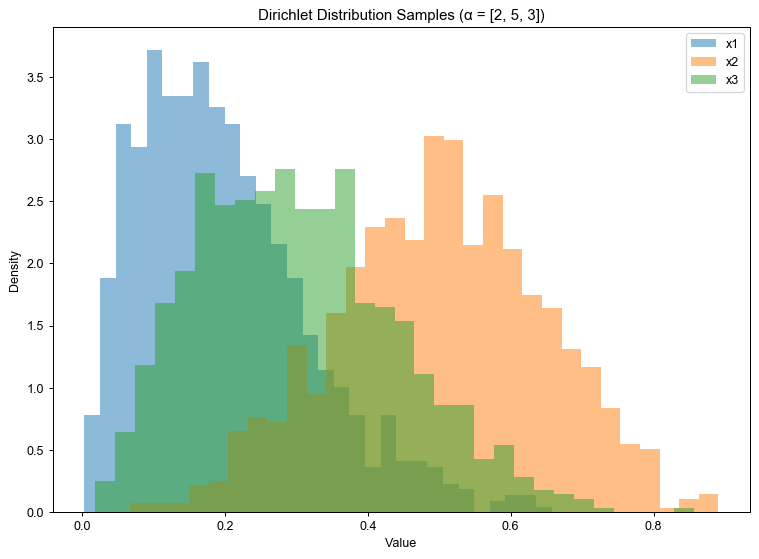

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置 Dirichlet 分布的 α 参数
alpha = [2, 5, 3]

# 生成 Dirichlet 分布样本
samples = np.random.dirichlet(alpha, size=1000)

# 可视化样本分布
plt.figure(figsize=(10, 7))
plt.hist(samples[:, 0], bins=30, alpha=0.5, label="x1", density=True)
plt.hist(samples[:, 1], bins=30, alpha=0.5, label="x2", density=True)
plt.hist(samples[:, 2], bins=30, alpha=0.5, label="x3", density=True)
plt.legend(loc="upper right")
plt.title("Dirichlet Distribution Samples (α = [2, 5, 3])")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

- `np.random.dirichlet(alpha, size=1000)`：从 Dirichlet 分布中采样 1000 个样本，每个样本为一个三维概率向量。
- `plt.hist()`：绘制每个类别的概率分布的直方图。
- `alpha = [2, 5, 3]`：定义了 Dirichlet 分布的参数向量，控制每个类别的“权重”。

![原文参考图，当前结果见代码输出](attachments/img_024.png)

该代码会绘制 3 个类别的概率直方图，展示 Dirichlet 分布在 1000 次采样中的样本分布。

## 机器学习中的应用

**LDA（Latent Dirichlet Allocation）模型**

在机器学习中，Dirichlet 分布的一个经典应用是 Latent Dirichlet Allocation（LDA）模型。

LDA 是一种主题模型，用于在大规模文档集中发现隐藏的主题。

LDA 假设每个文档都是由多个主题的概率分布混合生成的，每个主题也是一个由单词构成的概率分布。

**Dirichlet 分布在 LDA 中的作用：**

- **文档的主题分布：** 假设每个文档的主题分布是通过从 Dirichlet 分布中采样得到的。
- **主题的单词分布：** 每个主题的单词分布也是通过 Dirichlet 分布来建模的。

In [3]:
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 示例文档集
documents = [
    "I love reading about machine learning",
    "Machine learning is amazing",
    "Deep learning models are powerful",
    "Artificial intelligence is the future",
    "I enjoy reading books about AI"
]

# 将文本转换为词频矩阵
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

# 创建 LDA 模型
lda = LatentDirichletAllocation(n_components=2, random_state=42)

# 训练 LDA 模型
lda.fit(X)

# 输出每个主题的单词分布
print("Topic Distribution:")
print(lda.components_)

# 输出每个文档的主题分布
print("\nDocument Topic Distribution:")
doc_topic_dist = lda.transform(X)
print(doc_topic_dist)

Topic Distribution:
[[2.47531691 1.49717745 0.5083759  0.5066061  0.50655728 1.49717745
  0.5066061  1.49717745 0.50655728 0.50655728 0.50767323 0.77490231
  1.39694235 0.97000572 0.5066061  0.5066061  2.47531499 0.50655728]
 [0.52468309 0.50282255 1.4916241  1.4933939  1.49344272 0.50282255
  1.4933939  0.50282255 1.49344272 1.49344272 2.49232677 3.22509769
  0.60305765 2.02999428 1.4933939  1.4933939  0.52468501 1.49344272]]

Document Topic Distribution:
[[0.74592895 0.25407105]
 [0.10808429 0.89191571]
 [0.08856168 0.91143832]
 [0.08804793 0.91195207]
 [0.91463122 0.08536878]]


- `CountVectorizer` 用于将文本转换为词频矩阵。
- `LatentDirichletAllocation` 训练 LDA 模型，提取出每个文档的主题分布。

### 最后

Dirichlet 分布是一种多维连续分布，广泛应用于生成概率向量，尤其是在贝叶斯推断和机器学习中。在 LDA 等模型中，Dirichlet 分布的应用使得模型能够灵活地处理文档的主题分布以及单词的主题分布，从而进行有效的文本分析。